In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/gurgaon_properties_missing_value_imputation.csv")
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
997,flat,gls avenue 51,sector 92,0.50,7812.0,3.0,3.0,1,0.0,Relatively New,579.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2842,flat,chintels paradiso,sector 109,1.97,7490.0,4.0,4.0,2,11.0,Relatively New,2380.0,0.0,1.0,0.0,1.0,0.0,0.0,49.0
976,flat,m3m woodshire,sector 107,0.75,5490.0,2.0,2.0,3+,14.0,Relatively New,1201.0,0.0,0.0,0.0,1.0,0.0,0.0,174.0
3075,flat,ireo victory valley,sector 67,4.75,13930.0,4.0,4.0,3+,0.0,Relatively New,3200.0,1.0,1.0,1.0,1.0,0.0,1.0,165.0
1387,flat,tulip purple,sector 69,1.92,8000.0,4.0,5.0,3+,5.0,Relatively New,2172.0,0.0,1.0,0.0,0.0,0.0,1.0,158.0


In [4]:
df.shape

(3554, 18)

In [5]:
# we will drop price_per_sqft and society , because price_per_sqft can be correlated with price and we will not ask user , thet in which society he want to buy.
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score'],
      dtype='object')

In [6]:
train_df = df.drop(columns=['society' , 'price_per_sqft'])

In [7]:
# next part is , identifying which features are going to be useful for our prediction.

## luxury score

<Axes: xlabel='luxury_score'>

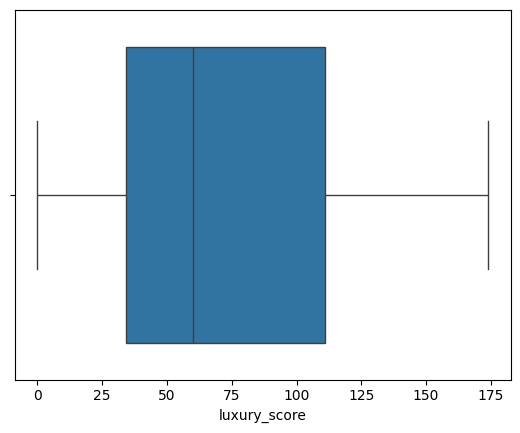

In [8]:
sns.boxplot(x = train_df['luxury_score'])

In [9]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return 'Low'
    elif 50 <= score < 150:
        return 'Medium'
    elif 150 <= score <= 175:
        return 'High'
    else:
        return None

In [10]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [11]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,Low
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,Low
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,Low
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,High
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,High


## floorNum

<Axes: xlabel='floorNum'>

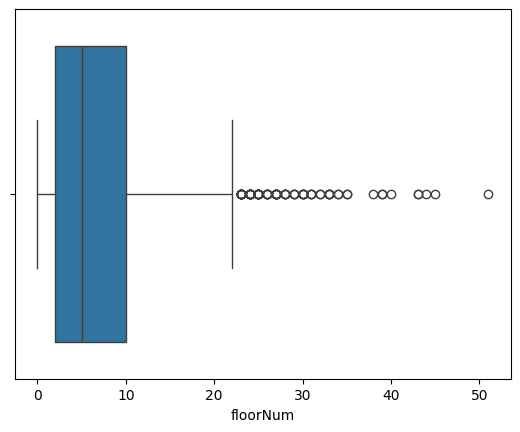

In [12]:
sns.boxplot(x = train_df['floorNum'])

In [13]:
def floornum_categorize(floorNum):
    if 0 <= floorNum < 3:
        return 'Low Floor'
    elif 3 <= floorNum < 11:
        return 'Mid Floor'
    elif 11 <= floorNum <= 51:
        return 'High Floor'
    else:
        return None

In [14]:
train_df['floor_category'] = train_df['floorNum'].apply(floornum_categorize)

In [15]:
train_df.head(
)

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,Low,Low Floor
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,Low,Mid Floor
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,Low,High Floor
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,High,Mid Floor
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,High,Mid Floor


In [16]:
train_df.drop(columns=['floorNum' , 'luxury_score'],inplace=True)

In [17]:
train_df.sample()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
1184,flat,sector 69,0.91,3.0,2.0,2,Moderately Old,1473.0,0.0,0.0,0.0,0.0,0.0,0.0,Low,High Floor


In [18]:
# cols in question
# numerical -> Luxury_category, others, floor_category
# categorical -› property_type, sector, agePossession

In [19]:
# out model can not understand english in category columns , so we have to convert them to number.

In [20]:
from sklearn.preprocessing import OrdinalEncoder

# creating copy of original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# apply label encoding to categorical cols.
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# splitting dataset into training and testing set.
X_label = data_label_encoded.drop('price',axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 10', 'sector 102', 'sector 103', 'sector 104',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 30', 'sector 31', 'sector 33',
       'sector 36', 'sector 37', 'sector 37d', 'sector 38', 'sector 39',
       'sector 4', 'sector 40', 'sector 41', 'sector 43', 'sector 45',
       'sector 46', 'sector 47', 'sector 48', 'sector 49', 'sector 5',
       'sector 50', 'sector 51', 'sector 52', 'sector 53', 'sector 54',
       'sector 55', 'sector 56', 'sector 57', 'sector 58', 'sector 59',
       'sector 6', 'sector 60', 'sector 61', 'sector 62', 

In [21]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,0.0,90.0,2.0,2.0,1.0,3.0,532.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
3550,1.0,12.0,5.0,5.0,4.0,3.0,6228.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
3551,0.0,23.0,1.0,1.0,1.0,0.0,665.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0
3552,1.0,44.0,5.0,6.0,3.0,0.0,5490.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0


In [22]:
y_label

,price
0,0.82
1,0.95
2,0.32
3,1.60
4,0.48
...,...
3549,0.37
3550,6.00
3551,0.60
3552,15.50


In [23]:
# now our datasets are ready for feature selection.

In [24]:
# I will apply 8 feature selection technique and will get feature importance score , for every feature and i will avg_out the score.

# Technique 1 - Correlation Analysis.

<Axes: >

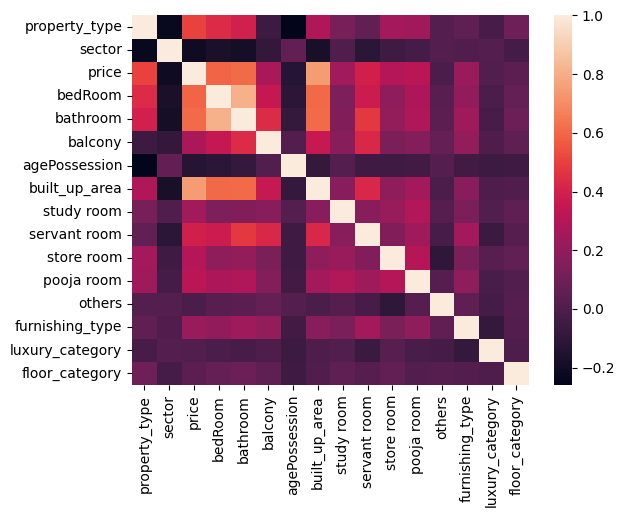

In [25]:
sns.heatmap(data_label_encoded.corr())

In [26]:
fi_df1 = data_label_encoded.corr()['price'].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,property_type,0.503728
1,sector,-0.212084
2,price,1.000000
3,bedRoom,0.591289
4,bathroom,0.609777
5,balcony,0.269637
6,agePossession,-0.134171
7,built_up_area,0.748574
8,study room,0.242955
9,servant room,0.391930


# Technique 2 - Random Forest Feature Importance.

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Train a random forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators = 100 , random_state = 42)
rf_label.fit(X_label , y_label)

# extract feature importance score from label encoded data
fi_df2 = pd.DataFrame({
    'feature':X_label.columns,
    'rf_importance':rf_label.feature_importances_
}).sort_values(by = 'rf_importance' , ascending = False)

In [28]:
fi_df2

,feature,rf_importance
6,built_up_area,0.650541
1,sector,0.102670
0,property_type,0.100079
3,bathroom,0.025882
2,bedRoom,0.024041
8,servant room,0.019320
5,agePossession,0.014519
4,balcony,0.012576
12,furnishing_type,0.010604
7,study room,0.008383


# Technique 3 - Gradient Boosting Feature importance.

In [29]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a gradient boosting regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label , y_label)

# extract feature importance score from label encoded data
fi_df3 = pd.DataFrame({
    'feature':X_label.columns,
    'gb_importance':gb_label.feature_importances_
}).sort_values(by = 'gb_importance' , ascending = False)

In [30]:
fi_df3

,feature,gb_importance
6,built_up_area,0.677877
1,sector,0.102642
0,property_type,0.098445
2,bedRoom,0.038197
3,bathroom,0.035952
8,servant room,0.023422
9,store room,0.010356
5,agePossession,0.004421
7,study room,0.003039
12,furnishing_type,0.002693


# Technique 4 - Permutation Importance.

In [31]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label , X_test_label , y_train_label , y_test_label = train_test_split(X_label , y_label , test_size = 0.2 , random_state = 42)

# Train a random forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators = 100 , random_state = 42)
rf_label.fit(X_train_label , y_train_label)

# calculate permutation importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# organize results into dataframe
fi_df4 = pd.DataFrame({
    'feature':X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by = 'permutation_importance' , ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.736026
0,property_type,0.200636
1,sector,0.178881
8,servant room,0.021018
3,bathroom,0.019884
2,bedRoom,0.018006
5,agePossession,0.004970
9,store room,0.002150
14,floor_category,0.000907
11,others,0.000792


# Technique 5 - LASSO

In [32]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'Ll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha = 0.01, random_state=42)
lasso.fit(X_scaled , y_label)

# extract coefficient
fi_df5 = pd.DataFrame({
    'feature':X_label.columns,
    'lasso_coeff':lasso.coef_
}).sort_values(by = 'lasso_coeff' , ascending = False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.510173
0,property_type,0.713829
3,bathroom,0.275042
9,store room,0.199655
7,study room,0.171846
12,furnishing_type,0.164113
8,servant room,0.160601
10,pooja room,0.073845
13,luxury_category,0.055268
2,bedRoom,0.014170


# Technique 6 - RFE

In [33]:
from sklearn.feature_selection import RFE

# intialize a base estimator
estimator = RandomForestRegressor()

# Apply RFE on label encoded and standardized training data.
selector_label = RFE(estimator , n_features_to_select = X_label.shape[1] , step =1)
selector_label = selector_label.fit(X_scaled , y_label)

# get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying Linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# organize results into dataframe
fi_df6 = pd.DataFrame({
    'feature':selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by = 'rfe_score' , ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.648184
1,sector,0.105138
0,property_type,0.102277
3,bathroom,0.024984
2,bedRoom,0.023983
8,servant room,0.022131
5,agePossession,0.014007
4,balcony,0.012582
12,furnishing_type,0.010135
7,study room,0.008356


# Technique 7 - Linear Regression Weights

In [34]:
from sklearn.linear_model import LinearRegression

# Apply Linear regression on label encoded and standardized training data.
lin_reg = LinearRegression()
lin_reg.fit(X_scaled , y_label)

# extract coeff
fi_df7 = pd.DataFrame({
    'feature':X_label.columns,
    'reg_coeffs':lin_reg.coef_
}).sort_values(by = 'reg_coeffs' , ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.512629
0,property_type,0.712890
3,bathroom,0.281976
9,store room,0.204159
7,study room,0.180048
12,furnishing_type,0.173192
8,servant room,0.169605
10,pooja room,0.076893
13,luxury_category,0.066472
2,bedRoom,0.016790


# Technique 8 - SHAP

In [35]:
!pip install shap

In [36]:
import shap

# compute shap values using a trained random forest model
# using rf_label model

explainer = shap.TreeExplainer(rf_label)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)
shap_values

array([[-1.80276388e-01,  1.16093247e-01, -2.49506459e-02, ...,
        -7.95356862e-03, -6.32991875e-03, -1.47989550e-02],
       [-2.03115731e-01, -3.91613891e-01, -3.95183345e-02, ...,
        -6.87727368e-03, -6.13941552e-03, -2.39072857e-03],
       [-1.80411756e-01, -4.09599055e-01, -4.24919746e-02, ...,
        -1.12498845e-02, -1.13058065e-02,  4.93406698e-03],
       ...,
       [-1.90131981e-01,  6.49122304e-02, -9.49042221e-03, ...,
         8.03903241e-03,  1.08107409e-02, -5.58026600e-04],
       [ 1.56836743e+00,  1.02886565e+00,  4.10159497e-01, ...,
         1.39971481e-01,  3.09288599e-02,  1.87306426e-02],
       [-3.27002675e-01, -5.86158388e-04, -1.72715693e-02, ...,
         2.77251092e-03, -8.27786557e-03,  4.01135092e-02]])

In [37]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.254438
0,property_type,0.472375
1,sector,0.354014
3,bathroom,0.133059
8,servant room,0.077607
2,bedRoom,0.045524
4,balcony,0.038071
7,study room,0.033261
12,furnishing_type,0.027560
5,agePossession,0.025656


In [38]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [39]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
property_type,0.503728,0.100079,0.098445,0.200636,0.713829,0.102277,0.712890,0.472375
sector,-0.212084,0.102670,0.102642,0.178881,-0.069634,0.105138,-0.078657,0.354014
bedRoom,0.591289,0.024041,0.038197,0.018006,0.014170,0.023983,0.016790,0.045524
bathroom,0.609777,0.025882,0.035952,0.019884,0.275042,0.024984,0.281976,0.133059
balcony,0.269637,0.012576,0.001748,-0.000432,-0.043562,0.012582,-0.066353,0.038071
agePossession,-0.134171,0.014519,0.004421,0.004970,-0.000000,0.014007,-0.002041,0.025656
built_up_area,0.748574,0.650541,0.677877,0.736026,1.510173,0.648184,1.512629,1.254438
study room,0.242955,0.008383,0.003039,-0.018027,0.171846,0.008356,0.180048,0.033261
servant room,0.391930,0.019320,0.023422,0.021018,0.160601,0.022131,0.169605,0.077607


In [42]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0) , axis=1)

In [43]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.621623
property_type,0.132112
sector,0.120957
bathroom,0.031281
bedRoom,0.023948
servant room,0.022725
agePossession,0.009470
balcony,0.008302
store room,0.007004


In [44]:
# to drop pooja room , study room , others
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,0.0,90.0,2.0,2.0,1.0,3.0,532.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
3550,1.0,12.0,5.0,5.0,4.0,3.0,6228.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
3551,0.0,23.0,1.0,1.0,1.0,0.0,665.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0
3552,1.0,44.0,5.0,6.0,3.0,0.0,5490.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0


In [45]:
# with all cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf , X_label , y_label , cv = 5 , scoring = 'r2')

In [46]:
scores.mean()

np.float64(0.8193190510339333)

In [47]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)

scores = cross_val_score(rf , X_label.drop(columns=['pooja room' , 'study room' , 'others']) , y_label , cv = 5 , scoring = 'r2')

In [48]:
scores.mean()

np.float64(0.8196500940616491)

In [49]:
export_df = X_label.drop(columns = ['pooja room' , 'study room' , 'others'])
export_df['price'] = y_label

In [50]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [51]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,1.0,1.0,0.82
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,0.0,0.0,1.0,2.0,0.95
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,1.0,0.0,0.32
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,1.0,0.0,1.0,0.0,2.0,1.60
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,1.0,0.0,0.0,2.0,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3549,0.0,90.0,2.0,2.0,1.0,3.0,532.0,0.0,0.0,0.0,2.0,2.0,0.37
3550,1.0,12.0,5.0,5.0,4.0,3.0,6228.0,1.0,1.0,0.0,0.0,1.0,6.00
3551,0.0,23.0,1.0,1.0,1.0,0.0,665.0,0.0,0.0,1.0,2.0,2.0,0.60
3552,1.0,44.0,5.0,6.0,3.0,0.0,5490.0,1.0,1.0,0.0,2.0,2.0,15.50
